<a href="https://colab.research.google.com/github/KrutikSibal02/ds-portfolio/blob/main/Spotify_Music_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

df = pd.read_csv('tracks.csv', engine='python', on_bad_lines='skip')
print(df.shape)
df.head()

(481077, 20)


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481077 entries, 0 to 481076
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                481077 non-null  object 
 1   name              481076 non-null  object 
 2   popularity        481077 non-null  int64  
 3   duration_ms       481077 non-null  int64  
 4   explicit          481077 non-null  int64  
 5   artists           481077 non-null  object 
 6   id_artists        481077 non-null  object 
 7   release_date      481077 non-null  object 
 8   danceability      481077 non-null  float64
 9   energy            481077 non-null  float64
 10  key               481077 non-null  int64  
 11  loudness          481077 non-null  float64
 12  mode              481077 non-null  int64  
 13  speechiness       481077 non-null  float64
 14  acousticness      481077 non-null  float64
 15  instrumentalness  481077 non-null  float64
 16  liveness          48

In [4]:
# Drop nulls and duplicates
df = df.dropna()
df = df.drop_duplicates(subset='id')

# Convert duration from ms to minutes
df['duration_min'] = df['duration_ms'] / 60000

# Extract year from release_date
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

print("Clean dataset shape:", df.shape)

Clean dataset shape: (481076, 22)


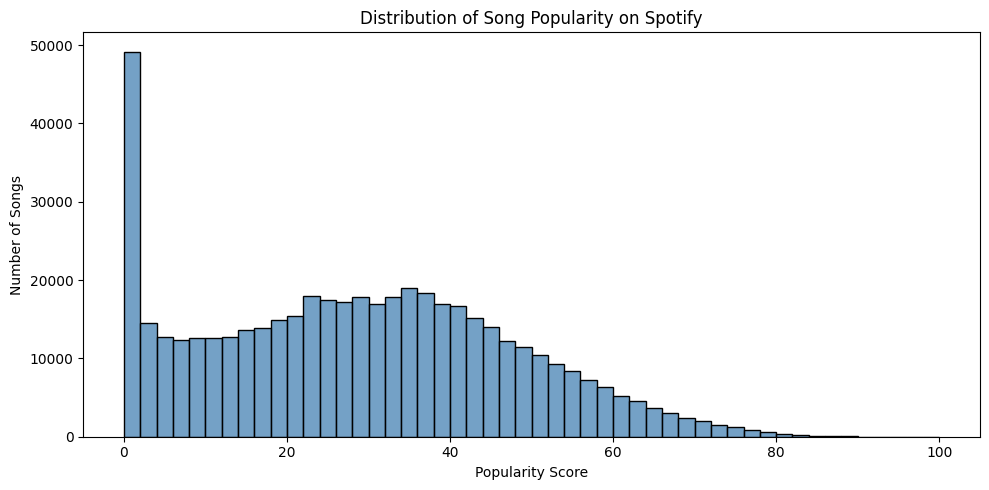

Average popularity: 28.11
Most songs have popularity below: 28.0


In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['popularity'], bins=50, color='steelblue')
plt.title('Distribution of Song Popularity on Spotify')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

print("Average popularity:", round(df['popularity'].mean(), 2))
print("Most songs have popularity below:", df['popularity'].median())

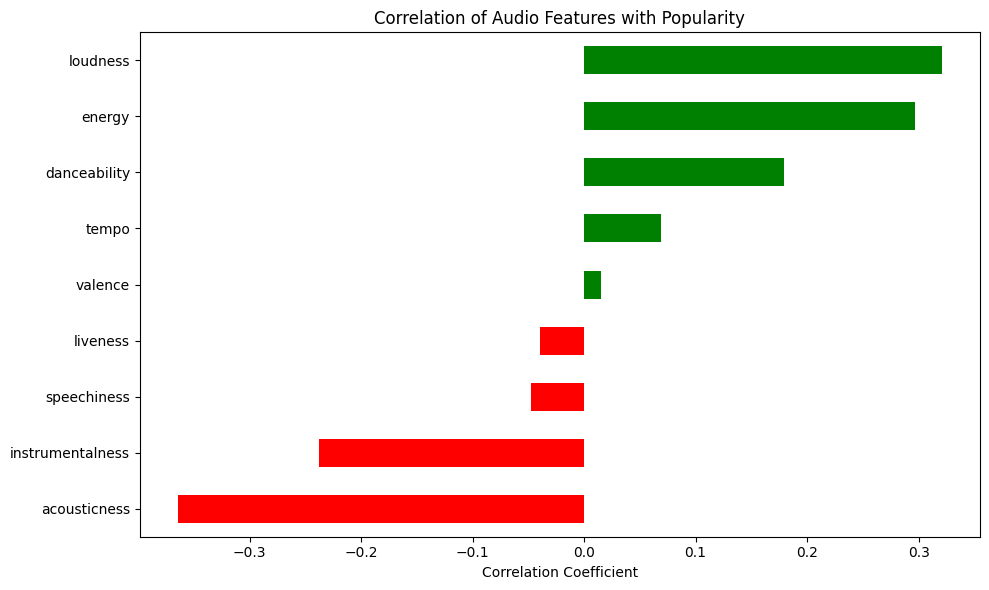

In [6]:
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

correlations = df[features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()

plt.figure(figsize=(10,6))
correlations.plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlations])
plt.title('Correlation of Audio Features with Popularity')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

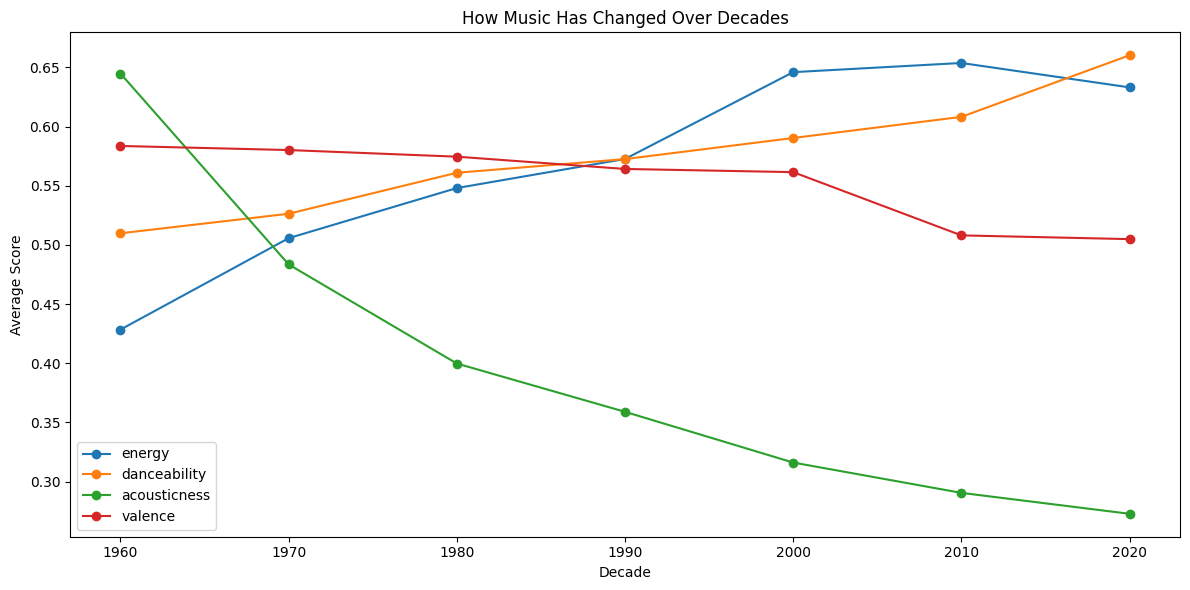

In [7]:
decade_df = df[df['year'] >= 1960].copy()
decade_df['decade'] = (decade_df['year'] // 10) * 10

decade_trends = decade_df.groupby('decade')[['energy', 'danceability', 'acousticness', 'valence']].mean()

plt.figure(figsize=(12,6))
for col in decade_trends.columns:
    plt.plot(decade_trends.index, decade_trends[col], marker='o', label=col)

plt.title('How Music Has Changed Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.show()

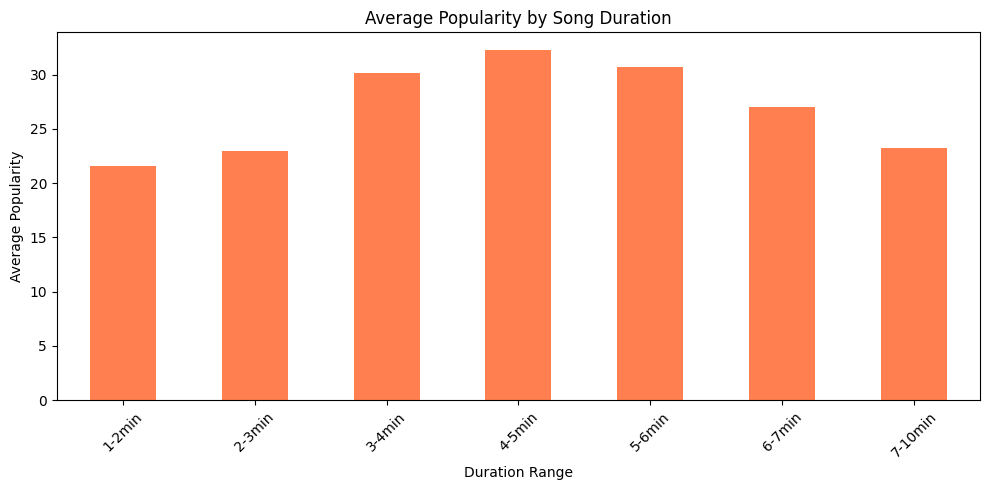

In [8]:
# Filter reasonable durations (1 to 10 minutes)
dur_df = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 10)].copy()
dur_df['duration_bucket'] = pd.cut(dur_df['duration_min'], bins=[1,2,3,4,5,6,7,10],
                                    labels=['1-2min','2-3min','3-4min','4-5min','5-6min','6-7min','7-10min'])

avg_pop = dur_df.groupby('duration_bucket', observed=True)['popularity'].mean()

plt.figure(figsize=(10,5))
avg_pop.plot(kind='bar', color='coral')
plt.title('Average Popularity by Song Duration')
plt.xlabel('Duration Range')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

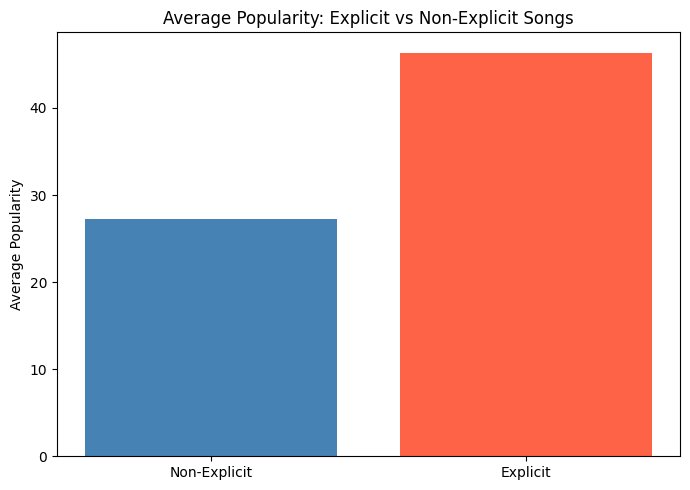

Explicit songs avg popularity: 46.37
Non-explicit songs avg popularity: 27.23


In [9]:
exp_pop = df.groupby('explicit')['popularity'].mean()
labels = ['Non-Explicit', 'Explicit']

plt.figure(figsize=(7,5))
plt.bar(labels, exp_pop.values, color=['steelblue', 'tomato'])
plt.title('Average Popularity: Explicit vs Non-Explicit Songs')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()

print("Explicit songs avg popularity:", round(exp_pop[1], 2))
print("Non-explicit songs avg popularity:", round(exp_pop[0], 2))

In [10]:
top10 = df[['name', 'artists', 'popularity', 'year']].sort_values('popularity', ascending=False).head(10)
top10['artists'] = top10['artists'].str[:30]
print("Top 10 Most Popular Songs:\n")
print(top10.to_string(index=False))

Top 10 Most Popular Songs:

                                              name                        artists  popularity   year
            Peaches (feat. Daniel Caesar & Giveon) ['Justin Bieber', 'Daniel Caes         100 2021.0
                                   drivers license             ['Olivia Rodrigo']          99 2021.0
                            Astronaut In The Ocean                ['Masked Wolf']          98 2021.0
                                         telepatía                 ['Kali Uchis']          97 2020.0
                                   Save Your Tears                 ['The Weeknd']          97 2020.0
                               Leave The Door Open ['Bruno Mars', 'Anderson .Paak          96 2021.0
                                   Blinding Lights                 ['The Weeknd']          96 2020.0
                                      The Business                     ['Tiësto']          95 2020.0
                                           Streets             

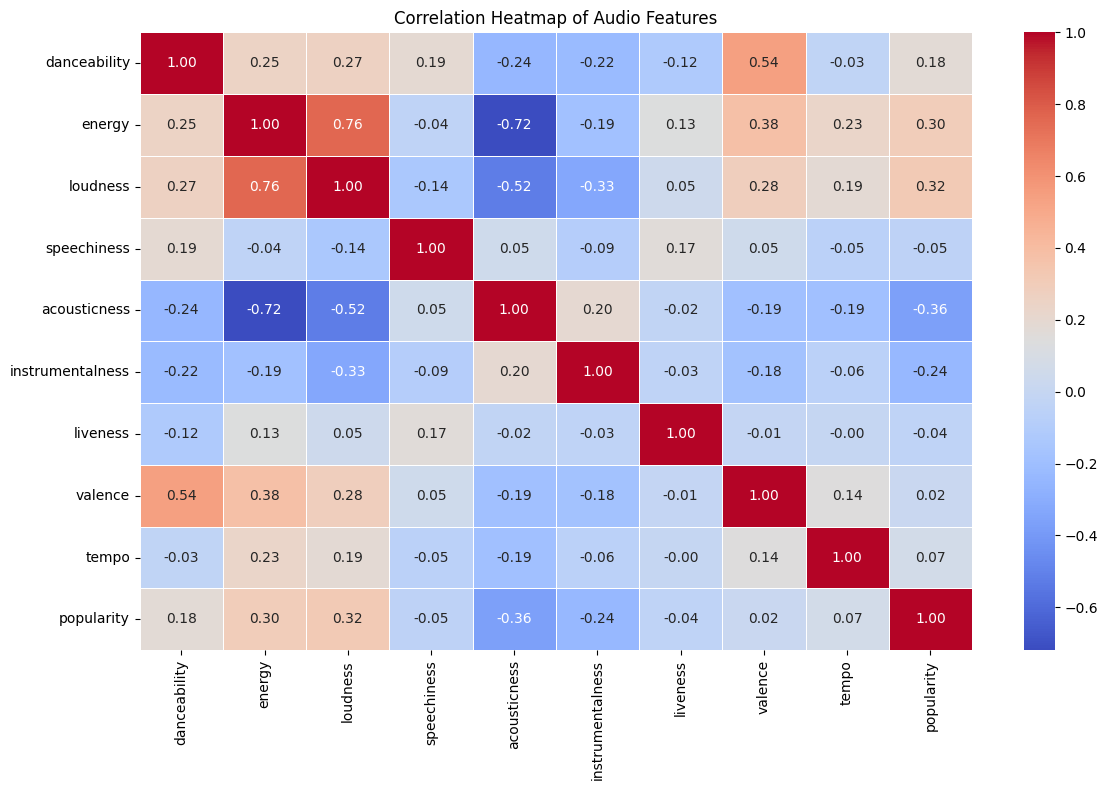

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df[features + ['popularity']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features')
plt.tight_layout()
plt.show()

Simple ML: Predict Popularity

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[features].dropna()
y = df.loc[X.index, 'popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))

MAE: 12.04
R2 Score: 0.35


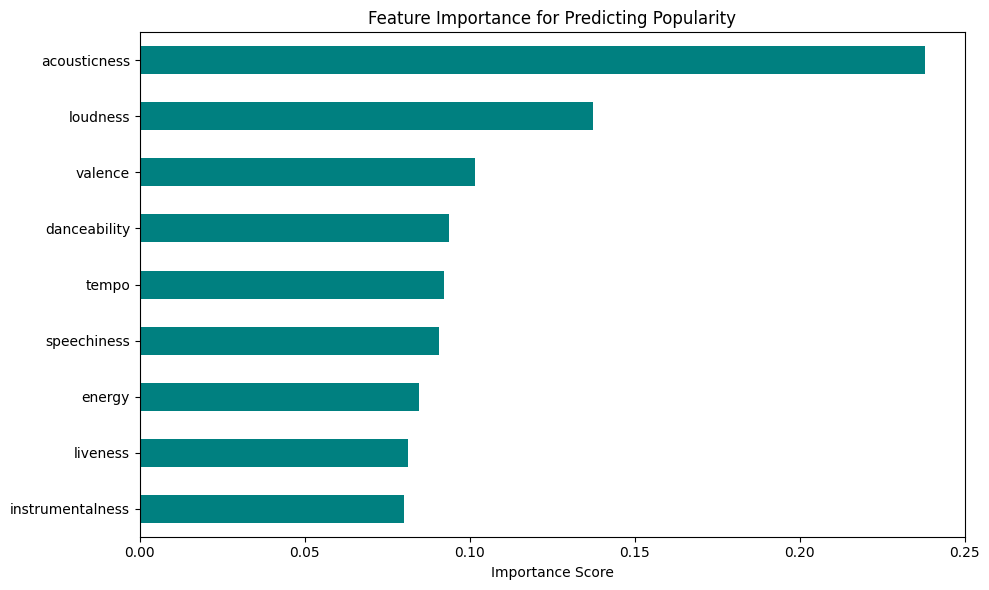

In [13]:
importance = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(10,6))
importance.plot(kind='barh', color='teal')
plt.title('Feature Importance for Predicting Popularity')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [15]:
# KEY INSIGHTS — Generated from actual analysis

most_common_pop = df['popularity'].mode()[0]
avg_pop = round(df['popularity'].mean(), 2)
best_duration = dur_df.groupby('duration_bucket', observed=True)['popularity'].mean().idxmax()
top_corr_feature = correlations.abs().idxmax()
top_corr_value = round(correlations.abs().max(), 3)
least_corr_feature = correlations.abs().idxmin()
explicit_avg = round(exp_pop[1], 2)
nonexplicit_avg = round(exp_pop[0], 2)
most_energetic_decade = decade_trends['energy'].idxmax()
least_acoustic_decade = decade_trends['acousticness'].idxmin()
mae = round(mean_absolute_error(y_test, y_pred), 2)
r2 = round(r2_score(y_test, y_pred), 2)
top_feature = pd.Series(model.feature_importances_, index=features).idxmax()

print(f"""
KEY INSIGHTS — Spotify Music Data Analysis
==========================================

1. POPULARITY: Average song popularity is {avg_pop}/100.
   Most songs cluster around {most_common_pop} — very few go viral.

2. AUDIO FEATURES: '{top_corr_feature}' has the strongest correlation
   with popularity (r={top_corr_value}). '{least_corr_feature}' has the weakest impact.

3. DECADES: Music was most energetic in the {most_energetic_decade}s.
   Acousticness hit its lowest point in the {least_acoustic_decade}s —
   reflecting the shift toward electronic and produced music.

4. DURATION: Songs in the '{best_duration}' range perform best on Spotify.
   Listeners prefer shorter, focused tracks on streaming platforms.

5. EXPLICIT CONTENT: Explicit songs average {explicit_avg} popularity
   vs {nonexplicit_avg} for non-explicit — a difference of {round(explicit_avg - nonexplicit_avg, 2)} points.

6. ML MODEL: Random Forest R2 = {r2}, MAE = {mae}.
   Top predictive feature: '{top_feature}'.
   Popularity beyond audio signals requires artist/marketing context.
""")


KEY INSIGHTS — Spotify Music Data Analysis

1. POPULARITY: Average song popularity is 28.11/100.
   Most songs cluster around 0 — very few go viral.

2. AUDIO FEATURES: 'acousticness' has the strongest correlation 
   with popularity (r=0.364). 'valence' has the weakest impact.

3. DECADES: Music was most energetic in the 2010.0s.
   Acousticness hit its lowest point in the 2020.0s — 
   reflecting the shift toward electronic and produced music.

4. DURATION: Songs in the '4-5min' range perform best on Spotify.
   Listeners prefer shorter, focused tracks on streaming platforms.

5. EXPLICIT CONTENT: Explicit songs average 46.37 popularity
   vs 27.23 for non-explicit — a difference of 19.14 points.

6. ML MODEL: Random Forest R2 = 0.35, MAE = 12.04.
   Top predictive feature: 'acousticness'.
   Popularity beyond audio signals requires artist/marketing context.

